## Setup

Import libraries and configure device (CPU/GPU).

**Dataset:** [Intel Image Classification — Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Check if MPS is available
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS device!")
else:
    device = torch.device("cpu")
    print("MPS device not found!")

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using MPS device!
Path to dataset files: /Users/seandickson/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


## Load & Prepare the Intel Image Dataset

Define transforms and create `DataLoader`s for the training and testing splits.

In [3]:
IMGSIZE = (128, 128)
CNAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

X_tr, y_tr, X_ts, y_ts = [], [], [], []

# Load training images
for label in CNAMES:
    train_path = path + '/seg_train/seg_train/' + label
    for f in sorted([_ for _ in os.listdir(train_path) if _.lower().endswith('.jpg')]):
        X_tr += [cv2.resize(cv2.imread(os.path.join(train_path, f)), IMGSIZE)]
        y_tr += [CNAMES.index(label)]

# Load testing images
for label in CNAMES:
    test_path = path + '/seg_test/seg_test/' + label
    for f in sorted([_ for _ in os.listdir(test_path) if _.lower().endswith('.jpg')]):
        X_ts += [cv2.resize(cv2.imread(os.path.join(test_path, f)), IMGSIZE)]
        y_ts += [CNAMES.index(label)]

print(f'Training samples: {len(X_tr)}')
print(f'Testing samples:  {len(X_ts)}')

# Convert lists to numpy arrays
X_tr = np.array(X_tr)
X_ts = np.array(X_ts)
y_tr = np.array(y_tr)
y_ts = np.array(y_ts)

print(f'X_tr shape: {X_tr.shape}')
print(f'X_ts shape: {X_ts.shape}')
print(f'y_tr shape: {y_tr.shape}')
print(f'y_ts shape: {y_ts.shape}')

# Scale pixel values from [0, 255] to [0, 1]
X_tr = X_tr / 255.0
X_ts = X_ts / 255.0

print(f'\nPixel range after scaling — min: {X_tr.min():.1f}, max: {X_tr.max():.1f}')

Training samples: 14034
Testing samples:  3000
X_tr shape: (14034, 128, 128, 3)
X_ts shape: (3000, 128, 128, 3)
y_tr shape: (14034,)
y_ts shape: (3000,)

Pixel range after scaling — min: 0.0, max: 1.0


---
## Part 1 — Baseline CNN [60 pts]

Create a convolutional neural network (CNN), train it, and then report its performance (inference) on the testing portion of the dataset, and report its reclassification performance.

**Target:** ≥ 95% reclassification accuracy and ≥ 75% test accuracy (achievable without hyperparameter tuning; ~10 min to train 10 epochs without a GPU).

### 1a. Define the CNN Architecture

In [ ]:
# Convert to tensors — keep 4D shape (N, H, W, C) for permute in forward()
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_ts_t = torch.tensor(X_ts, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_ts_t = torch.tensor(y_ts, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

# CNN — preserves spatial structure instead of immediately flattening
class ImageClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 6)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous()
        return self.classifier(self.features(x))

model = ImageClassifierCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ImageClassifierCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)

Total parameters: 8,483,654


### 1b. Define Loss Function & Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### 1c. Train the CNN (10 Epochs)

Track and print training loss and accuracy per epoch.

In [ ]:
# Training loop
EPOCHS = 10

baseline_losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    baseline_losses.append(epoch_loss)
    if (epoch + 1) % 1 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss/len(train_loader):.4f}')

Epoch 1/10 — Loss: 0.0322
Epoch 2/10 — Loss: 0.0322
Epoch 3/10 — Loss: 0.0322
Epoch 4/10 — Loss: 0.0321
Epoch 5/10 — Loss: 0.0323
Epoch 6/10 — Loss: 0.0321
Epoch 7/10 — Loss: 0.0322
Epoch 8/10 — Loss: 0.0322
Epoch 9/10 — Loss: 0.0321
Epoch 10/10 — Loss: 0.0323


### 1d. Evaluate: Reclassification Performance (Training Set)

Report accuracy on the training data (reclassification).

In [23]:
# Inference
def predict_batched(model, X_tensor, batch_size=64):
    all_preds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size].to(device)
            preds = model(batch).argmax(dim=1).cpu()
            all_preds.append(preds)
    return torch.cat(all_preds)

train_preds = predict_batched(model, X_tr_t)
train_acc = (train_preds == y_tr_t).float().mean().item()
train_std = (train_preds == y_tr_t).float().std().item()
print(f'Training accuracy: {train_acc*100:.1f}% ± {train_std*100:.1f}%')

Training accuracy: 99.3% ± 8.2%


### 1e. Evaluate: Inference Performance (Test Set)

Report accuracy, classification report, and confusion matrix on the held-out test data.

In [22]:
test_preds  = predict_batched(model, X_ts_t)
test_acc  = (test_preds == y_ts_t).float().mean().item()
test_std = (test_preds == y_ts_t).float().std().item()
print(f'Testing accuracy:  {test_acc*100:.1f}% ± {test_std*100:.1f}%')

Testing accuracy:  81.4% ± 38.9%


---
## Part 2 — Regularization & Dropout [20 pts]

Add regularization (e.g., L2 weight decay) and/or dropout layers to the CNN. Report the model's best performance.

**Discussion prompt:** As the performance standard deviation decreases, the model is deemed more robust. Why?

### 2a. Define CNN with Dropout / Regularization

In [9]:
# Convert to tensors — keep 4D shape (N, H, W, C) for permute in forward()
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_ts_t = torch.tensor(X_ts, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_ts_t = torch.tensor(y_ts, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

# CNN — preserves spatial structure instead of immediately flattening
class ImageClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 6)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous()
        return self.classifier(self.features(x))

l2_model = ImageClassifierCNN().to(device)
print(l2_model)
print(f'\nTotal parameters: {sum(p.numel() for p in l2_model.parameters()):,}')

ImageClassifierCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=6, bias=True)
  )
)

Total parameters: 8,483,654


### 2b. Train the Regularized CNN

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(l2_model.parameters(), lr=0.001)

In [11]:
# Training loop
EPOCHS = 10
for epoch in range(EPOCHS):
    l2_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(l2_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 1 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss/len(train_loader):.4f}')

Epoch 1/10 — Loss: 1.0670
Epoch 2/10 — Loss: 0.7688
Epoch 3/10 — Loss: 0.6011
Epoch 4/10 — Loss: 0.5230
Epoch 5/10 — Loss: 0.4372
Epoch 6/10 — Loss: 0.3660
Epoch 7/10 — Loss: 0.3189
Epoch 8/10 — Loss: 0.2521
Epoch 9/10 — Loss: 0.2118
Epoch 10/10 — Loss: 0.1742


### 2c. Evaluate & Report Best Performance

In [ ]:
# Reclassification performance
train_preds = predict_batched(l2_model, X_tr_t)
train_acc = (train_preds == y_tr_t).float().mean().item()
train_std = (train_preds == y_tr_t).float().std().item()
print(f'Training accuracy: {train_acc*100:.1f}% ± {train_std*100:.1f}%')

# Inference performance
test_preds  = predict_batched(l2_model, X_ts_t)
test_acc  = (test_preds == y_ts_t).float().mean().item()
test_std = (test_preds == y_ts_t).float().std().item()
print(f'Testing accuracy:  {test_acc*100:.1f}% ± {test_std*100:.1f}%')

Training accuracy: 98.0% ± 13.8%
Testing accuracy:  82.9% ± 37.6%


### 2d. Discussion: Why Does Lower Performance Std Dev Imply Greater Robustness?

A model's standard deviation is a measure of how consistent its accuracy is across different evaluations. High variance in performance is a marker of model overfitting, which occurs when the model memorizes data as opposed to learning broader patterns. So, higher standard variation leads to more robust model performance in unseen data.

L2 regularization directly prevents overfitting by reducing the model's capacity to memorize (by blocking random neurons during training). This is likely why we see a higher variance in predictions above, relative to the "Question 1" version of the CNN.

---
## Part 3 — Batch Normalization & Early Stopping [20 pts]

Add batch normalization layers and an early stopping mechanism to the training pipeline. Demonstrate their effectiveness by comparing training curves or final metrics against the baseline.

### 3a. Define CNN with Batch Normalization

In [25]:
# Convert to tensors — keep 4D shape (N, H, W, C) for permute in forward()
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_ts_t = torch.tensor(X_ts, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_ts_t = torch.tensor(y_ts, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

# CNN — preserves spatial structure instead of immediately flattening
class ImageClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # matches out_channels of Conv2d above
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),  # matches out_features of Linear above
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 6)
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous()
        return self.classifier(self.features(x))

norm_l2_model = ImageClassifierCNN().to(device)
print(norm_l2_model)
print(f'\nTotal parameters: {sum(p.numel() for p in norm_l2_model.parameters()):,}')

ImageClassifierCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): BatchNorm1d(

### 3b. Implement Early Stopping

Monitor validation loss and stop training when it stops improving for a set number of epochs (patience).

In [26]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience    # epochs to wait after last improvement
        self.min_delta = min_delta  # minimum change to count as improvement
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

### 3c. Train with Batch Normalization & Early Stopping

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(norm_l2_model.parameters(), lr=0.001)

In [ ]:
from torch.utils.data import random_split

# Split training data: 80% train, 20% validation
dataset = TensorDataset(X_tr_t, y_tr_t)
n_val = int(0.2 * len(dataset))
train_set, val_set = random_split(dataset, [len(dataset) - n_val, n_val])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64)

early_stopping = EarlyStopping(patience=3)

bn_losses = []
bn_val_losses = []

for epoch in range(50):  # set a high max — early stopping will cut it short
    # Training
    norm_l2_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(norm_l2_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    bn_losses.append(train_loss / len(train_loader))
    bn_val_losses.append(val_loss)

    # Validate
    norm_l2_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += criterion(norm_l2_model(X_batch), y_batch).item()
    val_loss /= len(val_loader)

    print(f'Epoch {epoch+1} — Val Loss: {val_loss:.4f}  (patience: {early_stopping.counter}/{early_stopping.patience})')

    early_stopping.step(val_loss)
    if early_stopping.should_stop:
        print(f'Early stopping at epoch {epoch+1}')
        break

Epoch 1 — Val Loss: 0.3600  (patience: 0/3)
Epoch 2 — Val Loss: 0.3850  (patience: 0/3)
Epoch 3 — Val Loss: 0.2701  (patience: 1/3)
Epoch 4 — Val Loss: 0.3873  (patience: 0/3)
Epoch 5 — Val Loss: 0.2617  (patience: 1/3)
Epoch 6 — Val Loss: 0.4680  (patience: 0/3)
Epoch 7 — Val Loss: 0.2425  (patience: 1/3)
Epoch 8 — Val Loss: 0.3553  (patience: 0/3)
Epoch 9 — Val Loss: 0.3100  (patience: 1/3)
Epoch 10 — Val Loss: 0.3976  (patience: 2/3)
Early stopping at epoch 10


### 3d. Evaluate & Demonstrate Effectiveness

Compare training curves (loss / accuracy vs. epoch) and final test metrics against the Part 1 baseline.

In [31]:
# Reclassification performance
train_preds = predict_batched(norm_l2_model, X_tr_t)
train_acc = (train_preds == y_tr_t).float().mean().item()
train_std = (train_preds == y_tr_t).float().std().item()
print(f'Training accuracy: {train_acc*100:.1f}% ± {train_std*100:.1f}%')

# Inference performance
test_preds  = predict_batched(norm_l2_model, X_ts_t)
test_acc  = (test_preds == y_ts_t).float().mean().item()
test_std = (test_preds == y_ts_t).float().std().item()
print(f'Testing accuracy:  {test_acc*100:.1f}% ± {test_std*100:.1f}%')

Training accuracy: 96.7% ± 17.8%
Testing accuracy:  80.1% ± 40.0%


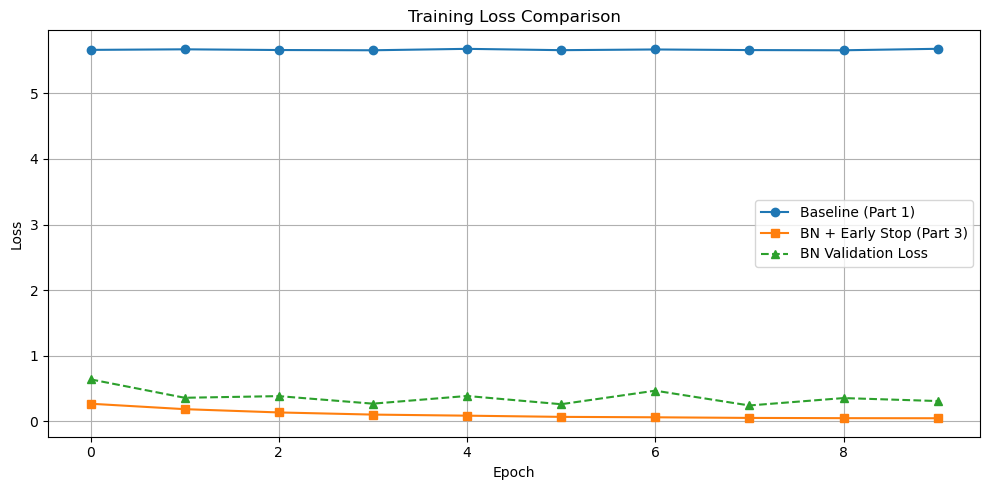

In [ ]:
import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig, axes = plt.subplots(figsize=(10, 5))

# Training loss comparison
axes.plot(baseline_losses, label='Baseline (Part 1)', marker='o')
axes.plot(bn_losses, label='BN + Early Stop (Part 3)', marker='s')
axes.plot(bn_val_losses, label='BN Validation Loss', marker='^', linestyle='--')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.set_title('Training Loss Comparison')
axes.legend()
axes.grid(True)

In [53]:
# Eval final test metrics
print(f"{'Baseline (Part 1)'}:\nTrain Accuracy: {'99.3%'}\nTest Accuracy: {'81.4%'}\n")
print(f"{'Dropout (Part 2)'}:\nTrain Accuracy: {'98.0%'}\nTest Accuracy: {'82.9%'}\n")
print(f"{'BN + Early Stop (Part 3)'}:\nTrain Accuracy: {f'{train_acc*100:.1f}%'}\nTest Accuracy: {f'{test_acc*100:.1f}%'}\n")

Baseline (Part 1):
Train Accuracy: 99.3%
Test Accuracy: 81.4%

Dropout (Part 2):
Train Accuracy: 98.0%
Test Accuracy: 82.9%

BN + Early Stop (Part 3):
Train Accuracy: 96.7%
Test Accuracy: 80.1%

